# STEP 5. H2 핵심 EDA

> **H2**: 골목상권의 순감소 위험이 높은 업종의 경우, 점포 규모와 유동인구를 맞추면 타 업종과 순감소 격차가 줄어들 것이다.

## 변수 역할

| 변수 | 원본 | 역할 |
|---|---|---|
| `y` | 점포-상권 (개업·폐업) | 결과변수 |
| `서비스_업종_코드_명` | 점포-상권 | 처리변수 |
| `log_점포수` | 점포-상권 | **매칭 공변량 ①** ★H2 명시 |
| `log_유동인구` | 길단위인구-상권 | **매칭 공변량 ②** ★H2 명시 |
| `log_면적` | 영역-상권 | 매칭 공변량 ③ |
| `log_집객시설` | 집객시설-상권 | 매칭 공변량 ④ |

## 진행 순서
5-1 업종별 순감소율 → 5-2 단순 격차 → 5-3 규모 교란 진단 → 5-4 SMD → 5-5 공통지지영역 → 5-6 검정

In [3]:
import sys, os
from pathlib import Path

# 노트북이 어디서 열리든 프로젝트 루트를 찾아 sys.path에 추가
ROOT = Path.cwd()
while not (ROOT / "config.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import numpy as np
import pandas as pd
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
print("프로젝트 루트:", ROOT)

프로젝트 루트: c:\Users\spide\ai-data-bootcamp\project\h2_nb


In [4]:
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from config import PROC, FIG, TARGET_TYPE, COVARIATES, set_korean_font
set_korean_font()
OUT = FIG.parent

def smd(a, b):
    """표준화 평균차. |SMD| < 0.1 이면 균형"""
    return (a.mean() - b.mean()) / np.sqrt((a.var() + b.var()) / 2)

d = pd.read_pickle(PROC / "03_panel.pkl")
gm = d[d["상권유형"] == TARGET_TYPE].copy()
print(f"{TARGET_TYPE} 요식업 표본 {len(gm):,}행 | 순감소율 {gm['y'].mean():.1%}")

골목상권 요식업 표본 30,367행 | 순감소율 24.4%


## 5-1. 업종별 순감소율 → 처리군 결정

처리군을 미리 정하지 않고 **데이터가 고르게** 합니다.

In [5]:
t = (gm.groupby("서비스_업종_코드_명")
     .agg(순감소율=("y", "mean"), 칸수=("y", "size"),
          평균점포=("점포_수", "mean"), 중앙유동인구=("총_유동인구_수", "median"))
     .sort_values("순감소율", ascending=False))
display(t.round(3))

TREAT = t.index[0]
gm["처리"] = (gm["서비스_업종_코드_명"] == TREAT).astype(int)
print(f"→ 처리군: {TREAT} (순감소율 {t.iloc[0]['순감소율']:.1%})")

,순감소율,칸수,평균점포,중앙유동인구
서비스_업종_코드_명,,,,
한식음식점,0.255,9776,20.155,793656.0
커피-음료,0.253,7060,11.900,921588.0
패스트푸드점,0.251,712,6.871,1534092.0
호프-간이주점,0.245,4350,11.469,1195142.0
분식전문점,0.234,3062,7.750,1318704.0
양식음식점,0.228,1378,11.186,1297408.5
일식음식점,0.225,910,8.347,1536589.5
제과점,0.217,1298,7.489,1366555.5
중식음식점,0.199,1105,9.889,1492068.0


→ 처리군: 한식음식점 (순감소율 25.5%)


## 5-2. 매칭 전 단순 격차

In [6]:
p1 = gm.loc[gm["처리"] == 1, "y"].mean()
p0 = gm.loc[gm["처리"] == 0, "y"].mean()
print(f"처리군 {TREAT}   n={int(gm['처리'].sum()):,}  순감소율 {p1:.1%}")
print(f"대조군 기타 외식  n={int((1-gm['처리']).sum()):,}  순감소율 {p0:.1%}")
print(f"\n단순 격차 = {p1-p0:+.1%}p   ← H2는 이 값이 매칭 후 줄어든다고 예측")

처리군 한식음식점   n=9,776  순감소율 25.5%
대조군 기타 외식  n=20,591  순감소율 23.8%

단순 격차 = +1.7%p   ← H2는 이 값이 매칭 후 줄어든다고 예측


## 5-3. 규모 교란 진단

격차가 업종 고유 위험이 아니라 규모 차이 때문일 수 있습니다. 규모 구간을 고정했을 때 격차가 어떻게 변하는지 봅니다. **매칭의 예고편**입니다.

In [7]:
r = np.corrcoef(t["평균점포"], t["순감소율"])[0, 1]
print(f"업종 평균점포수 ↔ 순감소율 상관 r = {r:.3f}")
print("r이 높으면 '업종 고유 위험'이 아니라 '규모 차이'일 가능성이 크다 → H2 지지 방향\n")

gm["규모구간"] = pd.qcut(gm["log_점포수"], 5, labels=[f"Q{i}" for i in range(1, 6)])
piv = gm.pivot_table(index="규모구간", columns="처리", values="y",
                     aggfunc=["mean", "size"], observed=True)
tbl = pd.DataFrame({
    "대조군_순감소율": piv[("mean", 0)], "처리군_순감소율": piv[("mean", 1)],
    "대조n": piv[("size", 0)].astype("Int64"), "처리n": piv[("size", 1)].astype("Int64")})
tbl["격차"] = tbl["처리군_순감소율"] - tbl["대조군_순감소율"]
display(tbl.round(3))
print("※ 구간 안에서 격차가 줄면 H2가 예측한 방향")
print("※ 한쪽 표본이 거의 없는 구간은 매칭 불가 영역")

업종 평균점포수 ↔ 순감소율 상관 r = 0.523
r이 높으면 '업종 고유 위험'이 아니라 '규모 차이'일 가능성이 크다 → H2 지지 방향



,대조군_순감소율,처리군_순감소율,대조n,처리n,격차
규모구간,,,,,
Q1,0.172,0.129,7889,1249,-0.043
Q2,0.216,0.145,4274,1081,-0.071
Q3,0.259,0.196,3404,1329,-0.063
Q4,0.311,0.255,2982,2098,-0.057
Q5,0.402,0.343,2042,4019,-0.059


※ 구간 안에서 격차가 줄면 H2가 예측한 방향
※ 한쪽 표본이 거의 없는 구간은 매칭 불가 영역


## 5-4. 공변량 균형 (SMD)

기준: |SMD| < 0.1 균형 / 0.1~0.25 불균형 / 0.25 초과 심각

매칭 **후** 모든 공변량이 0.1 미만이 되어야 "조건을 맞췄다"고 말할 수 있습니다.

In [8]:
rows = []
for c in COVARIATES:
    a = gm.loc[gm["처리"] == 1, c]
    b = gm.loc[gm["처리"] == 0, c]
    s = smd(a, b)
    rows.append({"공변량": c, "처리군평균": a.mean(), "대조군평균": b.mean(), "SMD": s,
                 "판정": "균형" if abs(s) < 0.1 else ("불균형" if abs(s) < 0.25 else "심각한 불균형")})
bal = pd.DataFrame(rows)
display(bal.round(3))
bal.to_csv(OUT / "h2_balance_before.csv", index=False, encoding="utf-8-sig")

,공변량,처리군평균,대조군평균,SMD,판정
0,log_점포수,2.742,2.152,0.944,심각한 불균형
1,log_유동인구,13.433,13.836,-0.440,심각한 불균형
2,log_면적,11.359,11.659,-0.464,심각한 불균형
3,log_집객시설,2.527,2.824,-0.420,심각한 불균형


## 5-5. 공통지지영역

겹치지 않는 구간의 관측치는 PSM에서 버려집니다.

**"격차가 줄었다"가 "격차를 만들던 관측치를 버렸다"일 수 있으므로**, 매칭 후 잔존 표본 수와 대표성을 반드시 함께 보고하세요.

In [9]:
for c in ["log_점포수", "log_유동인구"]:
    a = gm.loc[gm["처리"] == 1, c]; b = gm.loc[gm["처리"] == 0, c]
    lo, hi = max(a.min(), b.min()), min(a.max(), b.max())
    keep = ((gm[c] >= lo) & (gm[c] <= hi)).mean()
    print(f"{c:12} 겹치는 구간 [{lo:.2f}, {hi:.2f}]  → 표본의 {keep:.1%} 포함")

log_점포수      겹치는 구간 [1.61, 4.79]  → 표본의 100.0% 포함
log_유동인구     겹치는 구간 [2.20, 15.76]  → 표본의 100.0% 포함


## 5-6. 카이제곱 + Cramér's V

전 분기를 풀링하면 같은 상권이 반복 관측되어 표본 크기가 부풀려집니다. 그래서 **단일 분기 단면**으로 검정합니다.

p가 아무리 작아도 V가 작으면 실질적 차이는 작습니다.

In [10]:
last_q = gm["기준_년분기_코드"].max()
one = gm[gm["기준_년분기_코드"] == last_q]
ct = pd.crosstab(one["처리"], one["y"])
chi2, p, dof, _ = chi2_contingency(ct, correction=False)
v = np.sqrt(chi2 / ct.values.sum())

print(f"단면 분기 {last_q}  n={ct.values.sum():,}")
display(ct)
print(f"chi2({dof}) = {chi2:.2f}, p = {p:.3g}, Cramér's V = {v:.3f}")

단면 분기 20254  n=2,772


y,0,1
처리,,
0,1516,428
1,615,213


chi2(1) = 4.49, p = 0.0341, Cramér's V = 0.040


## 5-7. 시각화

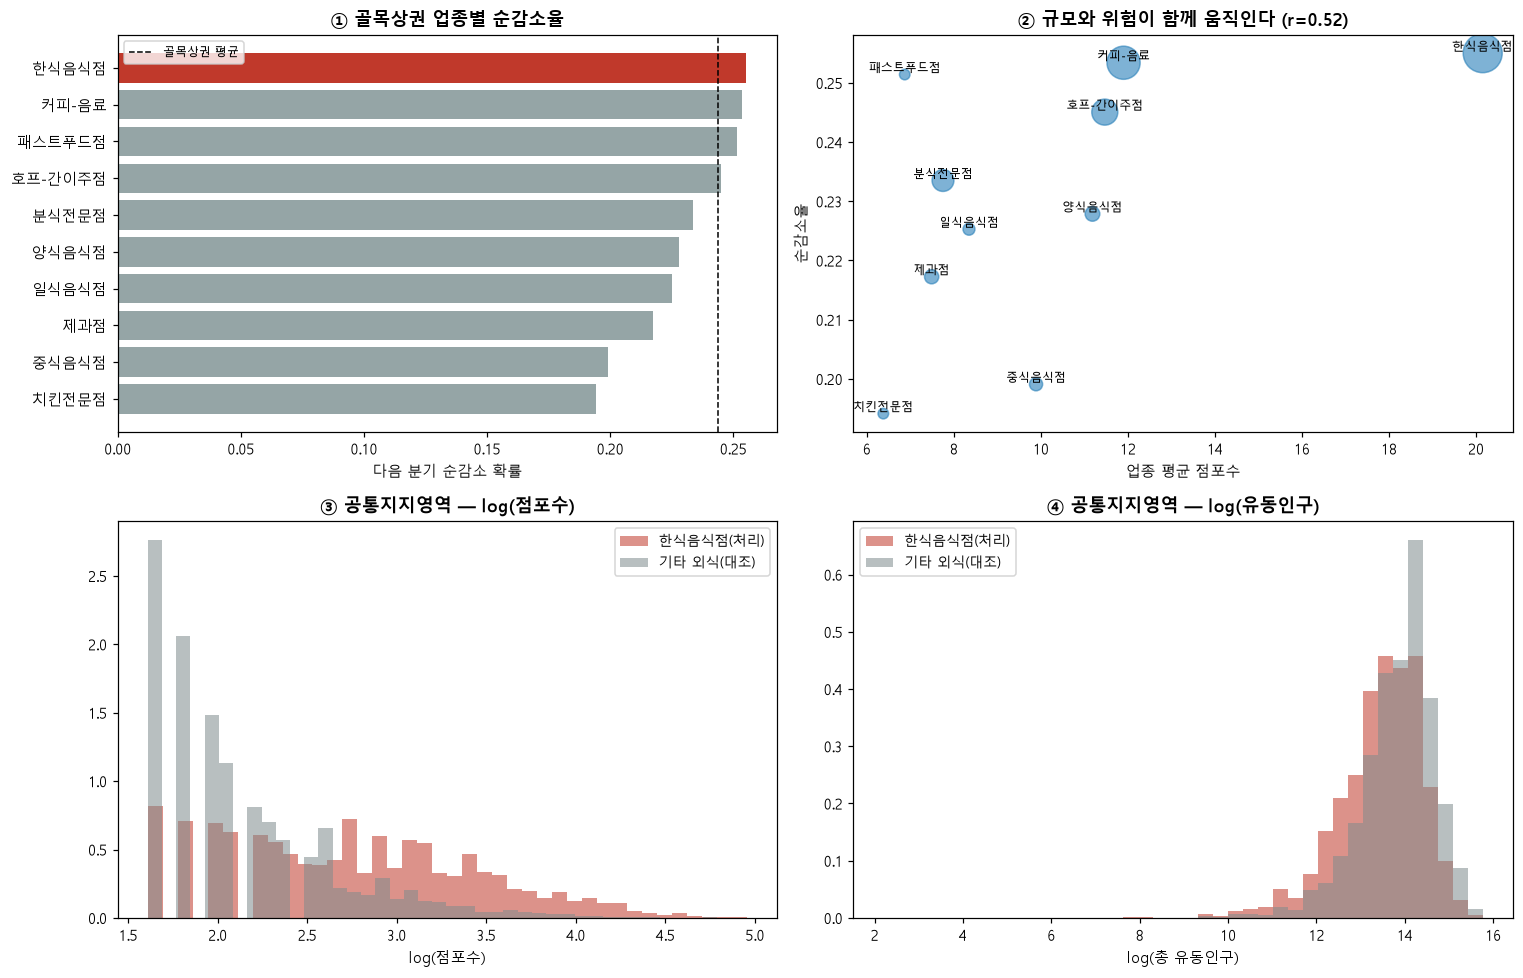

In [11]:
fig, ax = plt.subplots(2, 2, figsize=(14, 9))

t2 = t.sort_values("순감소율")
colors = ["#c0392b" if i == TREAT else "#95a5a6" for i in t2.index]
ax[0,0].barh(t2.index, t2["순감소율"], color=colors)
ax[0,0].axvline(gm["y"].mean(), ls="--", c="k", lw=1, label=f"{TARGET_TYPE} 평균")
ax[0,0].set_title(f"① {TARGET_TYPE} 업종별 순감소율", weight="bold")
ax[0,0].set_xlabel("다음 분기 순감소 확률"); ax[0,0].legend(fontsize=8)

ax[0,1].scatter(t["평균점포"], t["순감소율"], s=t["칸수"]/15, alpha=.6, c="#2980b9")
for i, row in t.iterrows():
    ax[0,1].annotate(i, (row["평균점포"], row["순감소율"]), fontsize=8, ha="center", va="bottom")
ax[0,1].set_xlabel("업종 평균 점포수"); ax[0,1].set_ylabel("순감소율")
ax[0,1].set_title(f"② 규모와 위험이 함께 움직인다 (r={r:.2f})", weight="bold")

for lab, sub, col in [(f"{TREAT}(처리)", gm[gm["처리"]==1], "#c0392b"),
                      ("기타 외식(대조)", gm[gm["처리"]==0], "#7f8c8d")]:
    ax[1,0].hist(sub["log_점포수"],   bins=40, alpha=.55, density=True, label=lab, color=col)
    ax[1,1].hist(sub["log_유동인구"], bins=40, alpha=.55, density=True, label=lab, color=col)
ax[1,0].set_title("③ 공통지지영역 — log(점포수)", weight="bold")
ax[1,0].set_xlabel("log(점포수)"); ax[1,0].legend(fontsize=9)
ax[1,1].set_title("④ 공통지지영역 — log(유동인구)", weight="bold")
ax[1,1].set_xlabel("log(총 유동인구)"); ax[1,1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG / "step5_h2_eda.png", dpi=130)
plt.show()

In [12]:
gm.to_pickle(PROC / "05_golmok.pkl")
print(f"[저장] 05_golmok.pkl  {gm.shape}  ← STEP 6(PSM) 입력")

[저장] 05_golmok.pkl  (30367, 38)  ← STEP 6(PSM) 입력
